<a href="https://colab.research.google.com/github/yogafaritonang-alt/Kelompok-2/blob/main/PrediksiCuaca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================================
# TUGAS KELOMPOK PRAKTIKUM MACHINE LEARNING
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, classification_report


In [2]:
# ---------------------------------------------------------
# 1. Dataset Bebas
# Contoh menggunakan dataset "Prediksi Cuaca" (Weather Prediction).
# ---------------------------------------------------------

# --- MEMBACA DATA DARI FILE CSV ---
# Pastikan file cuaca.csv sudah diunggah ke Google Colab
df = pd.read_csv('cuaca.csv')

X = df[['Suhu', 'Kelembaban', 'Kecepatan_Angin']]
y = df['Target']

# Label untuk hasil print dan visualisasi
nama_kelas = ['Cerah (0)', 'Hujan (1)']

print("Data Prediksi Cuaca:")
print(df.head())

Data Prediksi Cuaca:
   Suhu  Kelembaban  Kecepatan_Angin  Target
0  29.5        78.2             12.5       0
1  31.2        65.0              8.4       0
2  26.8        88.5             15.2       1
3  28.0        70.1             10.0       0
4  25.5        92.0             18.5       1


/tmp/ipykernel_1371/2252476866.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Target', data=df, palette='Set2')


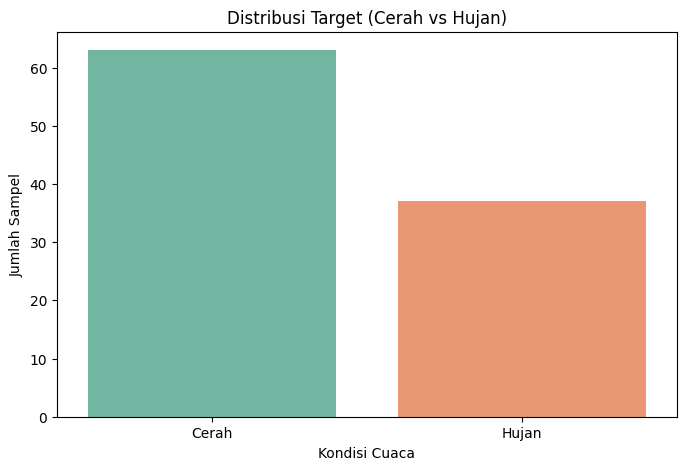

In [3]:
# ---------------------------------------------------------
# 2. Eksplorasi (EDA)
# Visualisasi data menggunakan grafik batang (bar chart)
# untuk melihat distribusi kelas (target).
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.countplot(x='Target', data=df, palette='Set2')
plt.title('Distribusi Target (Cerah vs Hujan)')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Jumlah Sampel')
plt.xticks(ticks=[0, 1], labels=['Cerah', 'Hujan'])
plt.show()


In [4]:
# ---------------------------------------------------------
# 3. Pemodelan
# Melatih data menggunakan dua algoritma klasifikasi berbeda:
# Logistic Regression dan K-Nearest Neighbors (KNN).
# ---------------------------------------------------------

# Split data menjadi Data Latih (80%) dan Data Uji (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model 1: Logistic Regression
log_reg_model = LogisticRegression(max_iter=10000, random_state=42)
log_reg_model.fit(X_train, y_train)
y_pred_log_reg = log_reg_model.predict(X_test)

# Model 2: K-Nearest Neighbors (KNN)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)


EVALUASI MODEL: Logistic Regression
Akurasi : 1.0000
Recall  : 1.0000

Classification Report:
              precision    recall  f1-score   support

   Cerah (0)       1.00      1.00      1.00        11
   Hujan (1)       1.00      1.00      1.00         9

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



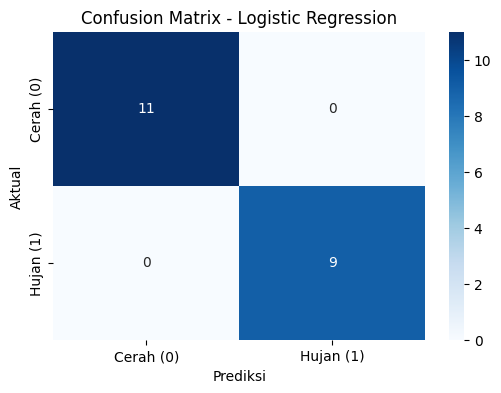


EVALUASI MODEL: K-Nearest Neighbors (KNN)
Akurasi : 1.0000
Recall  : 1.0000

Classification Report:
              precision    recall  f1-score   support

   Cerah (0)       1.00      1.00      1.00        11
   Hujan (1)       1.00      1.00      1.00         9

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



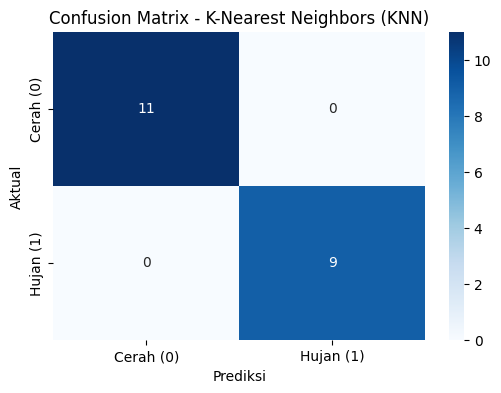

In [5]:
# ---------------------------------------------------------
# 4. Evaluasi & Analisa
# Menampilkan Confusion Matrix, Akurasi, dan Recall.
# ---------------------------------------------------------

def tampilkan_evaluasi(y_aktual, y_prediksi, nama_model):
    print(f"\n{'='*40}")
    print(f"EVALUASI MODEL: {nama_model}")
    print(f"{'='*40}")

    # Menghitung Akurasi dan Recall
    akurasi = accuracy_score(y_aktual, y_prediksi)
    # Gunakan average='binary' karena target kita cuma 2 kelas (Cerah/Hujan)
    recall = recall_score(y_aktual, y_prediksi, average='binary')

    print(f"Akurasi : {akurasi:.4f}")
    print(f"Recall  : {recall:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_aktual, y_prediksi, target_names=nama_kelas))

    # Visualisasi Confusion Matrix
    cm = confusion_matrix(y_aktual, y_prediksi)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=nama_kelas,
                yticklabels=nama_kelas)
    plt.title(f'Confusion Matrix - {nama_model}')
    plt.ylabel('Aktual')
    plt.xlabel('Prediksi')
    plt.show()

# Menjalankan evaluasi untuk kedua model
tampilkan_evaluasi(y_test, y_pred_log_reg, "Logistic Regression")
tampilkan_evaluasi(y_test, y_pred_knn, "K-Nearest Neighbors (KNN)")

In [6]:
# ---------------------------------------------------------
# 5. Simulasi AI (Menguji Model dengan Data Baru)
# (Tambahan ekstra agar terlihat seperti AI sungguhan!)
# ---------------------------------------------------------
print("\n" + "="*40)
print("MENGUJI AI DENGAN KONDISI CUACA BARU")
print("="*40)

# Anggaplah ini adalah data cuaca hari ini.
# Anda bisa mengganti angka-angka ini sesuka hati untuk mengetes AI!
suhu_hari_ini = 26.5         # Celcius
kelembaban_hari_ini = 88   # Persen
angin_hari_ini = 16.5        # km/h

print(f"Pertanyaan ke AI: 'Jika Suhu {suhu_hari_ini}°C, Kelembaban {kelembaban_hari_ini}%, dan Angin {angin_hari_ini} km/h, apakah akan hujan?'\n")

# Mengubah input menjadi format tabel yang dipahami AI
data_baru = pd.DataFrame([[suhu_hari_ini, kelembaban_hari_ini, angin_hari_ini]],
                         columns=['Suhu', 'Kelembaban', 'Kecepatan_Angin'])

# Meminta AI menebak (memprediksi)
hasil_log_reg = log_reg_model.predict(data_baru)[0]
hasil_knn = knn_model.predict(data_baru)[0]

# Menampilkan jawaban AI
print("Jawaban AI:")
print(f"🤖 Menurut Logistic Regression : Besok kemungkinan {nama_kelas[hasil_log_reg]}")
print(f"🤖 Menurut K-Nearest Neighbors : Besok kemungkinan {nama_kelas[hasil_knn]}")



MENGUJI AI DENGAN KONDISI CUACA BARU
Pertanyaan ke AI: 'Jika Suhu 26.5°C, Kelembaban 88%, dan Angin 16.5 km/h, apakah akan hujan?'

Jawaban AI:
🤖 Menurut Logistic Regression : Besok kemungkinan Hujan (1)
🤖 Menurut K-Nearest Neighbors : Besok kemungkinan Hujan (1)
